Using device: mps
Loading model: google/siglip-base-patch16-224

=== Font size summary ===
Best-fit single-line font size for "requests-darwin-lite": 21
Best-fit single-line font size for "requests": 49
Shared fixed single-line font size that fits BOTH on one line: 21
Shared last-char-overflow font size for "requests-darwin-lite": 22
At that size, "requests-darwin-lit" fits but "requests-darwin-lite" does not.
Character-wrapped lines at last-char-overflow size: ['requests-darwin-lit', 'e']

=== SigLIP cosine similarities ===
Best-fit single-line similarity ("requests-darwin-lite" vs "requests"): 0.786332
Shared fixed single-line similarity ("requests-darwin-lite" vs "requests"): 0.794065
Last-char-overflow shared-font similarity ("requests-darwin-lite" wrapped vs "requests"): 0.758649


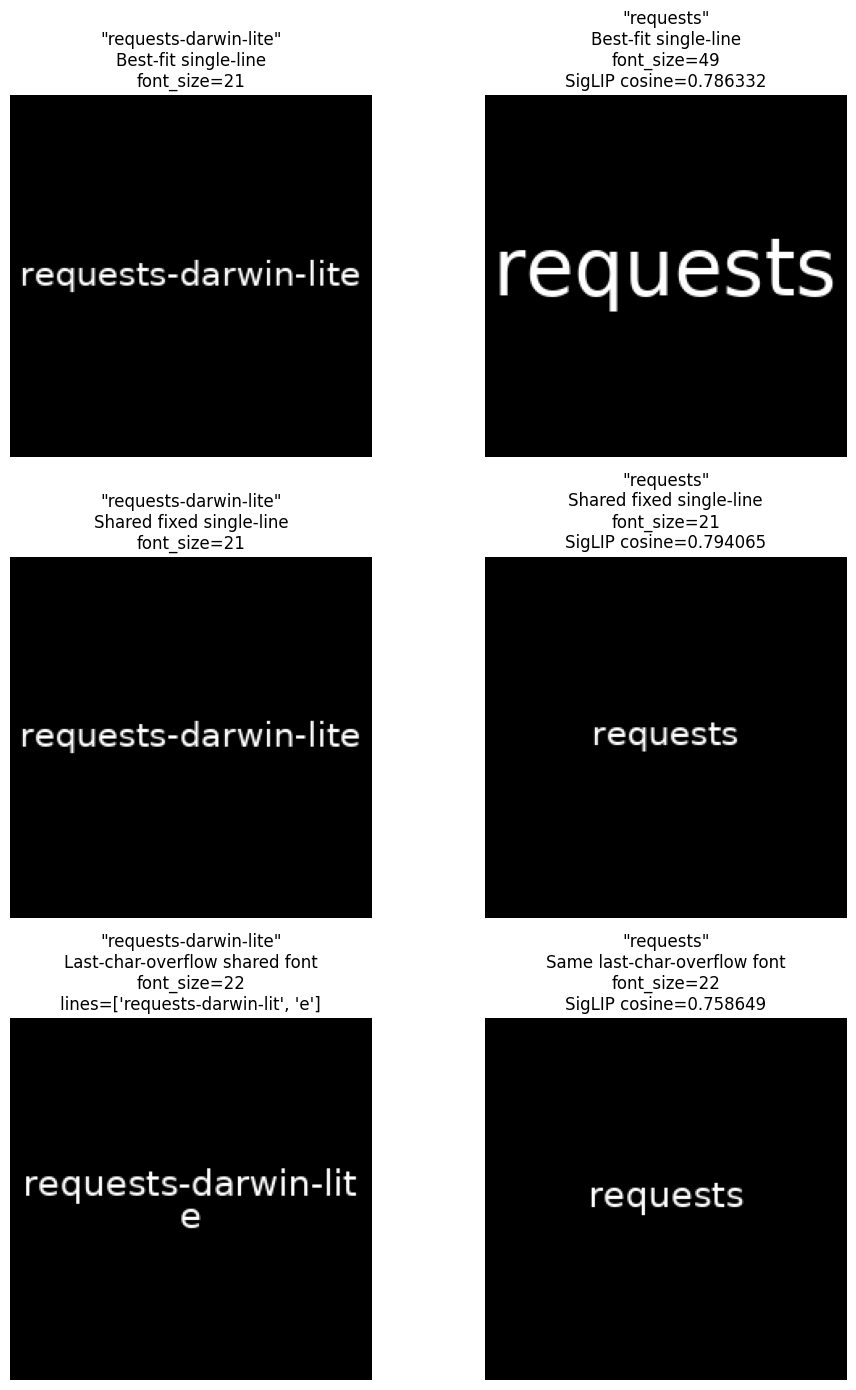

In [6]:
# Full notebook cell: render text as glyph images, compute SigLIP image-encoder cosine similarities,
# and plot:
#   1) individually best-fit single-line images for "requests-darwin-lite" and "requests"
#   2) both strings at one shared fixed font size that fits BOTH on one line
#   3) both strings at one shared font size where:
#        "requests-darwin-lit" fits on one line
#        but adding the final "e" makes "requests-darwin-lite" overflow
#      then render the long one with CHARACTER-LEVEL wrapping so only the overflowing tail moves down
#
# Notes:
# - Uses SigLIP image encoder only (vision model) and cosine similarity on normalized image embeddings.
# - Uses DejaVu Sans via matplotlib font manager.

import unicodedata
from functools import lru_cache
from typing import List, Tuple

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from matplotlib import font_manager
from transformers import AutoProcessor, SiglipVisionModel


# ============================================================
# Config
# ============================================================
TEXT_LONG = "requests-darwin-lite"
TEXT_SHORT = "requests"

MODEL_NAME = "google/siglip-base-patch16-224"
IMAGE_SIZE = (224, 224)
PAD = 4
BASE_FONT_SIZE = 120
MIN_FONT_SIZE = 1
MAX_FONT_CAP = 1024

# Adaptive HD rendering for best-fit cases
HD_ENABLED = True
HD_THRESHOLD = 10
HD_MIN_SCALE = 2
HD_MAX_SCALE = 8
HD_TARGET_FONT_PX = 28


# ============================================================
# Font helpers
# ============================================================
@lru_cache(maxsize=1)
def _get_font_path() -> str:
    return font_manager.findfont("DejaVu Sans", fallback_to_default=False)

@lru_cache(maxsize=4096)
def _get_font(font_size: int) -> ImageFont.FreeTypeFont:
    return ImageFont.truetype(_get_font_path(), int(font_size))


# ============================================================
# Measurement helpers
# ============================================================
def _measure_text(draw: ImageDraw.ImageDraw, text: str, font: ImageFont.FreeTypeFont) -> Tuple[int, int, int, int]:
    """
    Returns (w, h, x0, y0) where x0,y0 are bbox origin offsets.
    """
    x0, y0, x1, y1 = draw.textbbox((0, 0), text, font=font)
    return (x1 - x0), (y1 - y0), x0, y0


def _measure_multiline_text(
    draw: ImageDraw.ImageDraw,
    lines: List[str],
    font: ImageFont.FreeTypeFont,
    line_spacing: int = 0,
) -> Tuple[int, int, List[Tuple[int, int, int, int]]]:
    metrics = []
    max_w = 0
    total_h = 0

    for i, line in enumerate(lines):
        w, h, x0, y0 = _measure_text(draw, line, font)
        metrics.append((w, h, x0, y0))
        max_w = max(max_w, w)
        total_h += h
        if i < len(lines) - 1:
            total_h += line_spacing

    return max_w, total_h, metrics


def _max_fitting_font_size_single_line(
    draw: ImageDraw.ImageDraw,
    text: str,
    allowed_w: int,
    allowed_h: int,
    base_font_size: int,
    min_font_size: int,
    max_font_cap: int,
) -> Tuple[int, int, int, int, int]:
    """
    Largest integer font size that fits on one line.
    Returns (fs, w, h, x0, y0).
    """
    min_fs = max(1, int(min_font_size))
    cap_fs = max(min_fs, int(max_font_cap))
    base_fs = max(min_fs, min(cap_fs, int(base_font_size)))

    font0 = _get_font(base_fs)
    w0, h0, _, _ = _measure_text(draw, text, font0)

    if w0 <= 0 or h0 <= 0:
        font = _get_font(min_fs)
        w, h, x0, y0 = _measure_text(draw, text, font)
        return min_fs, w, h, x0, y0

    scale = min(allowed_w / w0, allowed_h / h0)
    est = int(base_fs * scale)
    est = max(min_fs, min(cap_fs, est))

    def fits(fs: int) -> bool:
        font = _get_font(fs)
        w, h, _, _ = _measure_text(draw, text, font)
        return (w <= allowed_w) and (h <= allowed_h)

    fs = est
    while fs > min_fs and not fits(fs):
        fs -= 1

    if fs == min_fs and not fits(fs):
        font = _get_font(min_fs)
        w, h, x0, y0 = _measure_text(draw, text, font)
        return min_fs, w, h, x0, y0

    lo = fs
    hi = min(cap_fs, lo + 1)
    while hi < cap_fs and fits(hi):
        lo = hi
        hi = min(cap_fs, hi * 2)

    if fits(hi):
        font = _get_font(hi)
        w, h, x0, y0 = _measure_text(draw, text, font)
        return hi, w, h, x0, y0

    low, high = lo, hi
    while low + 1 < high:
        mid = (low + high) // 2
        if fits(mid):
            low = mid
        else:
            high = mid

    font = _get_font(low)
    w, h, x0, y0 = _measure_text(draw, text, font)
    return low, w, h, x0, y0


def _does_fit_single_line(
    draw: ImageDraw.ImageDraw,
    text: str,
    font_size: int,
    allowed_w: int,
    allowed_h: int,
) -> bool:
    font = _get_font(font_size)
    w, h, _, _ = _measure_text(draw, text, font)
    return (w <= allowed_w) and (h <= allowed_h)


# ============================================================
# Wrapping helpers
# ============================================================
def _wrap_text_by_width_hyphen_aware(
    draw: ImageDraw.ImageDraw,
    text: str,
    font: ImageFont.FreeTypeFont,
    allowed_w: int,
) -> List[str]:
    """
    Greedy width-based wrapping, preferring hyphen boundaries.
    """
    parts = text.split("-")
    if len(parts) == 1:
        parts = [text]

    tokens = []
    for i, p in enumerate(parts):
        tokens.append(p + ("-" if i < len(parts) - 1 else ""))

    lines = []
    current = ""

    def fits(s: str) -> bool:
        w, _, _, _ = _measure_text(draw, s, font)
        return w <= allowed_w

    for tok in tokens:
        candidate = current + tok
        if current == "":
            if fits(tok):
                current = tok
            else:
                chunk = ""
                for ch in tok:
                    cand = chunk + ch
                    if chunk == "" or fits(cand):
                        chunk = cand
                    else:
                        lines.append(chunk)
                        chunk = ch
                current = chunk
        else:
            if fits(candidate):
                current = candidate
            else:
                lines.append(current)
                if fits(tok):
                    current = tok
                else:
                    chunk = ""
                    for ch in tok:
                        cand = chunk + ch
                        if chunk == "" or fits(cand):
                            chunk = cand
                        else:
                            lines.append(chunk)
                            chunk = ch
                    current = chunk

    if current:
        lines.append(current)

    return lines


def _wrap_text_by_width_char_only(
    draw: ImageDraw.ImageDraw,
    text: str,
    font: ImageFont.FreeTypeFont,
    allowed_w: int,
) -> List[str]:
    """
    Greedy character-level wrapping only.
    This is what we want for the last plot so the longest fitting prefix stays
    on the first line and only the overflowing tail drops to the next line.
    """
    lines = []
    current = ""

    def fits(s: str) -> bool:
        w, _, _, _ = _measure_text(draw, s, font)
        return w <= allowed_w

    for ch in text:
        candidate = current + ch
        if current == "" or fits(candidate):
            current = candidate
        else:
            lines.append(current)
            current = ch

    if current:
        lines.append(current)

    return lines


def _wrapped_layout_fits(
    draw: ImageDraw.ImageDraw,
    text: str,
    font_size: int,
    allowed_w: int,
    allowed_h: int,
    line_spacing_ratio: float = 0.15,
    wrap_mode: str = "hyphen",
) -> Tuple[bool, List[str], int]:
    font = _get_font(font_size)
    spacing = max(0, int(round(font_size * line_spacing_ratio)))

    if wrap_mode == "char":
        lines = _wrap_text_by_width_char_only(draw, text, font, allowed_w)
    else:
        lines = _wrap_text_by_width_hyphen_aware(draw, text, font, allowed_w)

    total_w, total_h, _ = _measure_multiline_text(draw, lines, font, spacing)
    ok = (total_w <= allowed_w) and (total_h <= allowed_h)
    return ok, lines, spacing


# ============================================================
# Rendering
# ============================================================
def render_single_line(
    text: str,
    image_size: Tuple[int, int] = (224, 224),
    pad: int = 4,
    min_font_size: int = 1,
    base_font_size: int = 120,
    max_font_cap: int = 1024,
    hd_enabled: bool = True,
    hd_threshold: int = 10,
    hd_min_scale: int = 2,
    hd_max_scale: int = 8,
    hd_target_font_px: int = 28,
    force_font_size: int = None,
) -> Tuple[Image.Image, int]:
    """
    Render exactly one line.
    Returns (image, font_size_used).
    """
    text = unicodedata.normalize("NFC", str(text))
    W, H = map(int, image_size)
    pad = int(pad)

    allowed_w = max(1, W - 2 * pad)
    allowed_h = max(1, H - 2 * pad)

    tmp = Image.new("RGB", (W, H), (0, 0, 0))
    tmp_draw = ImageDraw.Draw(tmp)

    if force_font_size is None:
        fs_native, _, _, _, _ = _max_fitting_font_size_single_line(
            draw=tmp_draw,
            text=text,
            allowed_w=allowed_w,
            allowed_h=allowed_h,
            base_font_size=base_font_size,
            min_font_size=min_font_size,
            max_font_cap=max_font_cap,
        )
    else:
        fs_native = int(force_font_size)

    use_hd = bool(
        hd_enabled
        and force_font_size is None
        and (fs_native <= int(hd_threshold))
        and (hd_max_scale >= 2)
    )

    if not use_hd:
        img = Image.new("RGB", (W, H), (0, 0, 0))
        draw = ImageDraw.Draw(img)
        font = _get_font(fs_native)
        w, h, x0, y0 = _measure_text(draw, text, font)
        x = (W - w) // 2 - x0
        y = (H - h) // 2 - y0
        draw.text((x, y), text, font=font, fill=(255, 255, 255))
        return img, fs_native

    target = max(1, int(hd_target_font_px))
    denom = max(1, int(fs_native))
    needed = int(np.ceil(target / denom))
    S = int(max(int(hd_min_scale), needed))
    S = int(min(int(hd_max_scale), max(2, S)))

    WR, HR = W * S, H * S
    pad_r = pad * S
    allowed_wr = max(1, WR - 2 * pad_r)
    allowed_hr = max(1, HR - 2 * pad_r)

    img_r = Image.new("RGB", (WR, HR), (0, 0, 0))
    draw_r = ImageDraw.Draw(img_r)

    fs_r, w_r, h_r, x0_r, y0_r = _max_fitting_font_size_single_line(
        draw=draw_r,
        text=text,
        allowed_w=allowed_wr,
        allowed_h=allowed_hr,
        base_font_size=base_font_size * S,
        min_font_size=max(1, min_font_size * S),
        max_font_cap=max_font_cap * S,
    )

    x_r = (WR - w_r) // 2 - x0_r
    y_r = (HR - h_r) // 2 - y0_r
    draw_r.text((x_r, y_r), text, font=_get_font(fs_r), fill=(255, 255, 255))

    img = img_r.resize((W, H), resample=Image.Resampling.LANCZOS)
    return img, fs_native


def render_wrapped_at_fixed_font(
    text: str,
    font_size: int,
    image_size: Tuple[int, int] = (224, 224),
    pad: int = 4,
    line_spacing_ratio: float = 0.15,
    wrap_mode: str = "hyphen",
) -> Tuple[Image.Image, List[str], int]:
    """
    Render wrapped text at a fixed font size.
    wrap_mode:
      - "hyphen" : prefers hyphen boundaries
      - "char"   : pure character-level wrapping
    Returns:
      (image, wrapped_lines, line_spacing_px)
    """
    text = unicodedata.normalize("NFC", str(text))
    W, H = map(int, image_size)
    pad = int(pad)

    allowed_w = max(1, W - 2 * pad)
    img = Image.new("RGB", (W, H), (0, 0, 0))
    draw = ImageDraw.Draw(img)

    font = _get_font(int(font_size))
    spacing = max(0, int(round(font_size * line_spacing_ratio)))

    if wrap_mode == "char":
        lines = _wrap_text_by_width_char_only(draw, text, font, allowed_w)
    else:
        lines = _wrap_text_by_width_hyphen_aware(draw, text, font, allowed_w)

    total_w, total_h, metrics = _measure_multiline_text(draw, lines, font, spacing)

    y = (H - total_h) // 2
    for i, line in enumerate(lines):
        w, h, x0, y0 = metrics[i]
        x = (W - w) // 2 - x0
        yy = y - y0
        draw.text((x, yy), line, font=font, fill=(255, 255, 255))
        y += h + (spacing if i < len(lines) - 1 else 0)

    return img, lines, spacing


def find_last_char_overflow_shared_font_size(
    long_text: str,
    short_text: str,
    image_size: Tuple[int, int] = (224, 224),
    pad: int = 4,
    min_font_size: int = 1,
    base_font_size: int = 120,
    max_font_cap: int = 1024,
    line_spacing_ratio: float = 0.15,
) -> Tuple[int, List[str], int]:
    """
    Find the smallest integer font size such that:
      - long_text[:-1] fits on one line
      - long_text does NOT fit on one line
      - short_text fits on one line
      - long_text fits when CHAR-WRAPPED

    This makes the last character be what pushes it over.
    """
    W, H = map(int, image_size)
    allowed_w = max(1, W - 2 * pad)
    allowed_h = max(1, H - 2 * pad)

    img = Image.new("RGB", image_size, (0, 0, 0))
    draw = ImageDraw.Draw(img)

    prefix = long_text[:-1]

    best_long_fit_fs, *_ = _max_fitting_font_size_single_line(
        draw=draw,
        text=long_text,
        allowed_w=allowed_w,
        allowed_h=allowed_h,
        base_font_size=base_font_size,
        min_font_size=min_font_size,
        max_font_cap=max_font_cap,
    )

    for fs in range(best_long_fit_fs, max_font_cap + 1):
        prefix_fits = _does_fit_single_line(draw, prefix, fs, allowed_w, allowed_h)
        long_fits = _does_fit_single_line(draw, long_text, fs, allowed_w, allowed_h)
        short_fits = _does_fit_single_line(draw, short_text, fs, allowed_w, allowed_h)

        if not prefix_fits:
            continue
        if long_fits:
            continue
        if not short_fits:
            continue

        wrapped_ok, lines, spacing = _wrapped_layout_fits(
            draw=draw,
            text=long_text,
            font_size=fs,
            allowed_w=allowed_w,
            allowed_h=allowed_h,
            line_spacing_ratio=line_spacing_ratio,
            wrap_mode="char",
        )
        if not wrapped_ok:
            continue

        return fs, lines, spacing

    raise RuntimeError(
        "Could not find an integer font size where only the last character pushes the long string over."
    )


# ============================================================
# SigLIP image embeddings
# ============================================================
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch_dtype = torch.float16 if device.type == "cuda" else torch.float32

print(f"Using device: {device}")
print(f"Loading model: {MODEL_NAME}")

model = SiglipVisionModel.from_pretrained(MODEL_NAME, torch_dtype=torch_dtype).to(device).eval()
try:
    processor = AutoProcessor.from_pretrained(MODEL_NAME, use_fast=True)
except TypeError:
    processor = AutoProcessor.from_pretrained(MODEL_NAME)


@torch.no_grad()
def siglip_embed_images(images: List[Image.Image]) -> torch.Tensor:
    batch = processor(images=images, return_tensors="pt")
    batch = {k: v.to(device) for k, v in batch.items()}

    if device.type == "cuda":
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            out = model(**batch)
    else:
        out = model(**batch)

    embs = out.pooler_output
    embs = F.normalize(embs, dim=-1, eps=1e-8)
    return embs


@torch.no_grad()
def cosine_similarity_between_images(img_a: Image.Image, img_b: Image.Image) -> float:
    embs = siglip_embed_images([img_a, img_b])
    sim = torch.sum(embs[0] * embs[1]).item()
    return float(sim)


# ============================================================
# 1) Individually best-fit single-line renders
# ============================================================
dummy_img = Image.new("RGB", IMAGE_SIZE, (0, 0, 0))
dummy_draw = ImageDraw.Draw(dummy_img)
allowed_w = IMAGE_SIZE[0] - 2 * PAD
allowed_h = IMAGE_SIZE[1] - 2 * PAD

best_long_fs, *_ = _max_fitting_font_size_single_line(
    draw=dummy_draw,
    text=TEXT_LONG,
    allowed_w=allowed_w,
    allowed_h=allowed_h,
    base_font_size=BASE_FONT_SIZE,
    min_font_size=MIN_FONT_SIZE,
    max_font_cap=MAX_FONT_CAP,
)

best_short_fs, *_ = _max_fitting_font_size_single_line(
    draw=dummy_draw,
    text=TEXT_SHORT,
    allowed_w=allowed_w,
    allowed_h=allowed_h,
    base_font_size=BASE_FONT_SIZE,
    min_font_size=MIN_FONT_SIZE,
    max_font_cap=MAX_FONT_CAP,
)

img_long_best, fs_long_best_used = render_single_line(
    TEXT_LONG,
    image_size=IMAGE_SIZE,
    pad=PAD,
    min_font_size=MIN_FONT_SIZE,
    base_font_size=BASE_FONT_SIZE,
    max_font_cap=MAX_FONT_CAP,
    hd_enabled=HD_ENABLED,
    hd_threshold=HD_THRESHOLD,
    hd_min_scale=HD_MIN_SCALE,
    hd_max_scale=HD_MAX_SCALE,
    hd_target_font_px=HD_TARGET_FONT_PX,
)

img_short_best, fs_short_best_used = render_single_line(
    TEXT_SHORT,
    image_size=IMAGE_SIZE,
    pad=PAD,
    min_font_size=MIN_FONT_SIZE,
    base_font_size=BASE_FONT_SIZE,
    max_font_cap=MAX_FONT_CAP,
    hd_enabled=HD_ENABLED,
    hd_threshold=HD_THRESHOLD,
    hd_min_scale=HD_MIN_SCALE,
    hd_max_scale=HD_MAX_SCALE,
    hd_target_font_px=HD_TARGET_FONT_PX,
)

sim_best = cosine_similarity_between_images(img_long_best, img_short_best)


# ============================================================
# 2) Shared fixed font size that works for BOTH on one line
# ============================================================
shared_fixed_fs = min(best_long_fs, best_short_fs)

img_long_fixed, _ = render_single_line(
    TEXT_LONG,
    image_size=IMAGE_SIZE,
    pad=PAD,
    min_font_size=MIN_FONT_SIZE,
    base_font_size=BASE_FONT_SIZE,
    max_font_cap=MAX_FONT_CAP,
    hd_enabled=False,
    force_font_size=shared_fixed_fs,
)

img_short_fixed, _ = render_single_line(
    TEXT_SHORT,
    image_size=IMAGE_SIZE,
    pad=PAD,
    min_font_size=MIN_FONT_SIZE,
    base_font_size=BASE_FONT_SIZE,
    max_font_cap=MAX_FONT_CAP,
    hd_enabled=False,
    force_font_size=shared_fixed_fs,
)

sim_fixed = cosine_similarity_between_images(img_long_fixed, img_short_fixed)


# ============================================================
# 3) Shared font size where only the final "e" pushes long over
# ============================================================
last_char_overflow_fs, last_char_lines, last_char_spacing = find_last_char_overflow_shared_font_size(
    long_text=TEXT_LONG,
    short_text=TEXT_SHORT,
    image_size=IMAGE_SIZE,
    pad=PAD,
    min_font_size=MIN_FONT_SIZE,
    base_font_size=BASE_FONT_SIZE,
    max_font_cap=MAX_FONT_CAP,
    line_spacing_ratio=0.15,
)

img_long_lastchar_wrapped, last_char_lines_used, _ = render_wrapped_at_fixed_font(
    TEXT_LONG,
    font_size=last_char_overflow_fs,
    image_size=IMAGE_SIZE,
    pad=PAD,
    line_spacing_ratio=0.15,
    wrap_mode="char",   # <-- critical fix
)

img_short_lastchar_same_fs, _ = render_single_line(
    TEXT_SHORT,
    image_size=IMAGE_SIZE,
    pad=PAD,
    min_font_size=MIN_FONT_SIZE,
    base_font_size=BASE_FONT_SIZE,
    max_font_cap=MAX_FONT_CAP,
    hd_enabled=False,
    force_font_size=last_char_overflow_fs,
)

sim_lastchar = cosine_similarity_between_images(img_long_lastchar_wrapped, img_short_lastchar_same_fs)


# ============================================================
# Print results
# ============================================================
print("\n=== Font size summary ===")
print(f'Best-fit single-line font size for "{TEXT_LONG}": {best_long_fs}')
print(f'Best-fit single-line font size for "{TEXT_SHORT}": {best_short_fs}')
print(f"Shared fixed single-line font size that fits BOTH on one line: {shared_fixed_fs}")
print(f'Shared last-char-overflow font size for "{TEXT_LONG}": {last_char_overflow_fs}')
print(f'At that size, "{TEXT_LONG[:-1]}" fits but "{TEXT_LONG}" does not.')
print(f'Character-wrapped lines at last-char-overflow size: {last_char_lines_used}')

print("\n=== SigLIP cosine similarities ===")
print(f'Best-fit single-line similarity ("{TEXT_LONG}" vs "{TEXT_SHORT}"): {sim_best:.6f}')
print(f'Shared fixed single-line similarity ("{TEXT_LONG}" vs "{TEXT_SHORT}"): {sim_fixed:.6f}')
print(f'Last-char-overflow shared-font similarity ("{TEXT_LONG}" wrapped vs "{TEXT_SHORT}"): {sim_lastchar:.6f}')


# ============================================================
# Plot all requested outputs
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(10, 14))

# Row 1: individually best-fit single-line
axes[0, 0].imshow(img_long_best)
axes[0, 0].set_title(f'"{TEXT_LONG}"\nBest-fit single-line\nfont_size={fs_long_best_used}')
axes[0, 0].axis("off")

axes[0, 1].imshow(img_short_best)
axes[0, 1].set_title(
    f'"{TEXT_SHORT}"\nBest-fit single-line\nfont_size={fs_short_best_used}\n'
    f'SigLIP cosine={sim_best:.6f}'
)
axes[0, 1].axis("off")

# Row 2: shared fixed font size, both single-line
axes[1, 0].imshow(img_long_fixed)
axes[1, 0].set_title(f'"{TEXT_LONG}"\nShared fixed single-line\nfont_size={shared_fixed_fs}')
axes[1, 0].axis("off")

axes[1, 1].imshow(img_short_fixed)
axes[1, 1].set_title(
    f'"{TEXT_SHORT}"\nShared fixed single-line\nfont_size={shared_fixed_fs}\n'
    f'SigLIP cosine={sim_fixed:.6f}'
)
axes[1, 1].axis("off")

# Row 3: shared font size where only the final character pushes long over
axes[2, 0].imshow(img_long_lastchar_wrapped)
axes[2, 0].set_title(
    f'"{TEXT_LONG}"\nLast-char-overflow shared font\nfont_size={last_char_overflow_fs}\nlines={last_char_lines_used}'
)
axes[2, 0].axis("off")

axes[2, 1].imshow(img_short_lastchar_same_fs)
axes[2, 1].set_title(
    f'"{TEXT_SHORT}"\nSame last-char-overflow font\nfont_size={last_char_overflow_fs}\n'
    f'SigLIP cosine={sim_lastchar:.6f}'
)
axes[2, 1].axis("off")

plt.tight_layout()
plt.show()